Dataset shape: (7022, 20)
Columns:
['Age', 'Course', 'Gender', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Financial_Stress', 'Extracurricular_Involvement', 'Semester_Credit_Load', 'Residence_Typetext']

All columns converted to numeric for correlation analysis.
Age                              int64
Course                            int8
Gender                            int8
CGPA                           float64
Stress_Level                     int64
Depression_Score                 int64
Anxiety_Score                    int64
Sleep_Quality                    int64
Physical_Activity                int64
Diet_Quality                     int64
Social_Support                   int64
Relationship_Status               int8
Substance_Use                     int8
Counseling_Service_Use            int

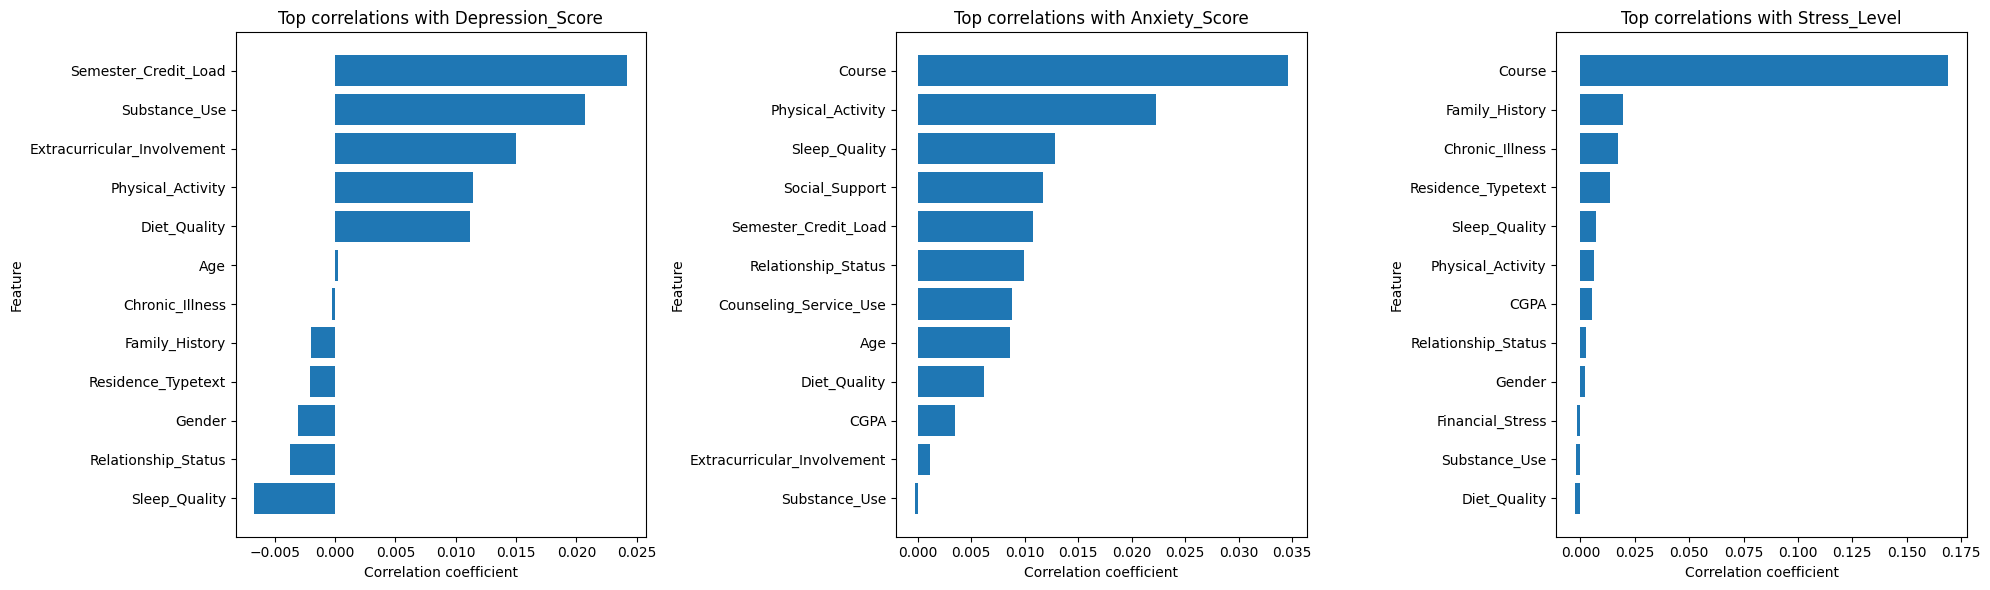

In [ ]:
import os
import json
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load dataset
# -----------------------------
dataset_dir = '../../Dataset'
file_path = f'{dataset_dir}/students_mental_health_survey.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())

# -----------------------------
# 2) Logical categorical -> numeric casting
# -----------------------------
# Start from a copy so original text values remain untouched
df_num = df.copy()

# Optional cleanup: ensure consistent text formatting before mapping
for col in df_num.select_dtypes(exclude='number').columns:
    df_num[col] = df_num[col].astype(str).str.strip()

# Binary-like logical maps (Yes/No, etc.)
binary_map = {
    'yes': 1, 'no': 0,
    'true': 1, 'false': 0,
    'y': 1, 'n': 0,
    'used': 1, 'not used': 0,
    'urban': 1, 'rural': 0,
    'hostel': 1, 'day scholar': 0
}

# Ordinal maps (logical order)
ordinal_maps = {
    'Sleep_Quality': {'Poor': 0, 'Average': 1, 'Good': 2},
    'Physical_Activity': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Diet_Quality': {'Poor': 0, 'Average': 1, 'Good': 2},
    'Social_Support': {'Low': 0, 'Moderate': 1, 'High': 2}
}

# Apply known ordinal mappings first
for col, mp in ordinal_maps.items():
    if col in df_num.columns:
        df_num[col] = df_num[col].map(mp)

# Apply binary maps to object columns where possible
for col in df_num.select_dtypes(exclude='number').columns:
    lowered = df_num[col].str.lower()
    mapped = lowered.map(binary_map)

    # Use mapped version only if it produced at least one valid mapping
    if mapped.notna().sum() > 0:
        df_num[col] = mapped

# For remaining non-numeric columns, use category codes (stable, complete numeric conversion)
remaining_obj = df_num.select_dtypes(exclude='number').columns.tolist()
for col in remaining_obj:
    df_num[col] = pd.Categorical(df_num[col]).codes

print('\nAll columns converted to numeric for correlation analysis.')
print(df_num.dtypes)

# -----------------------------
# 3) Save numeric dataset + metadata in Dataset folder
# -----------------------------
numeric_csv_path = f'{dataset_dir}/students_mental_health_survey_numeric.csv'
metadata_json_path = f'{dataset_dir}/students_mental_health_survey_numeric_metadata.json'

df_num.to_csv(numeric_csv_path, index=False)

metadata = {
    'source_file': 'students_mental_health_survey.csv',
    'numeric_file': 'students_mental_health_survey_numeric.csv',
    'created_at_utc': datetime.utcnow().isoformat(),
    'rows': int(df_num.shape[0]),
    'columns': int(df_num.shape[1]),
    'dtypes': {col: str(dtype) for col, dtype in df_num.dtypes.items()},
    'numeric_columns': df_num.select_dtypes(include='number').columns.tolist(),
    'non_numeric_columns': df_num.select_dtypes(exclude='number').columns.tolist()
}

with open(metadata_json_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f"\nSaved numeric dataset: {os.path.abspath(numeric_csv_path)}")
print(f"Saved metadata JSON: {os.path.abspath(metadata_json_path)}")

# -----------------------------
# 4) Use metadata further (reload and use for correlation pipeline)
# -----------------------------
with open(metadata_json_path, 'r', encoding='utf-8') as f:
    metadata_loaded = json.load(f)

available_numeric_cols = [
    c for c in metadata_loaded['numeric_columns']
    if c in df_num.columns
]

print(f"\nMetadata-driven numeric columns count: {len(available_numeric_cols)}")

# -----------------------------
# 5) Correlation helper function
# -----------------------------
def correlation_with_target(dataframe, target_col, exclude_cols, allowed_columns):
    available_exclude = [c for c in exclude_cols if c in dataframe.columns]
    cols_for_corr = [
        c for c in allowed_columns
        if c not in set(available_exclude + [target_col])
    ]

    corr_series = (
        dataframe[cols_for_corr + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    return corr_series

# -----------------------------
# 6) Three requested correlations (metadata-driven)
# -----------------------------
# (1) Depression vs all other columns except Anxiety & Stress
corr_depression = correlation_with_target(
    df_num,
    target_col='Depression_Score',
    exclude_cols=['Anxiety_Score', 'Stress_Level'],
    allowed_columns=available_numeric_cols
)

# (2) Anxiety vs all other columns except Depression & Stress
corr_anxiety = correlation_with_target(
    df_num,
    target_col='Anxiety_Score',
    exclude_cols=['Depression_Score', 'Stress_Level'],
    allowed_columns=available_numeric_cols
)

# (3) Stress vs all other columns except Anxiety & Depression
stress_target = 'Stress_Level' if 'Stress_Level' in df_num.columns else None
if stress_target is None:
    raise ValueError("Could not find stress score column. Expected 'Stress_Level'.")

corr_stress = correlation_with_target(
    df_num,
    target_col=stress_target,
    exclude_cols=['Anxiety_Score', 'Depression_Score'],
    allowed_columns=available_numeric_cols
)

# -----------------------------
# 7) Print correlation tables
# -----------------------------
print('\n' + '=' * 80)
print('1) Depression_Score vs all other columns (excluding Anxiety_Score, Stress_Level)')
print('=' * 80)
print(corr_depression)

print('\n' + '=' * 80)
print('2) Anxiety_Score vs all other columns (excluding Depression_Score, Stress_Level)')
print('=' * 80)
print(corr_anxiety)

print('\n' + '=' * 80)
print('3) Stress_Level vs all other columns (excluding Anxiety_Score, Depression_Score)')
print('=' * 80)
print(corr_stress)

# -----------------------------
# 8) Visualize top relationships for each target
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, corr_data, title in [
    (axes[0], corr_depression, 'Depression_Score'),
    (axes[1], corr_anxiety, 'Anxiety_Score'),
    (axes[2], corr_stress, stress_target),
]:
    top_corr = corr_data.sort_values(ascending=False).head(12)
    y_pos = np.arange(len(top_corr))
    ax.barh(y_pos, top_corr.values)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_corr.index)
    ax.invert_yaxis()
    ax.set_title(f'Top correlations with {title}')
    ax.set_xlabel('Correlation coefficient')
    ax.set_ylabel('Feature')

plt.tight_layout()

output_png = 'correlation_top_relationships.png'
fig.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"\nSaved plot: {os.path.abspath(output_png)}")

plt.show()
